Import relevant libraries

In [41]:
import sklearn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
import warnings # keeps output clean
warnings.filterwarnings('ignore')
np.random.seed(42) #for userability
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import normalize
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve

Random Forest

Shape of target variable and features!

In [42]:
from sklearn.datasets import fetch_openml

dataset = fetch_openml(data_id=4538, as_frame=False)
X = dataset.data
y = dataset.target


print('shape of features: x', X.shape)
print('shape of targets: y', y.data.shape)

shape of features: x (9873, 32)
shape of targets: y (9873,)


Splitting the dataset into training and testing data (70% training and 30% testing), as well as, creating a confusion matrix heatmap and a classification report of the raw data.

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3,random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix", confusion_matrix(y_test, y_pred))
print('Balanced Accuracy score', balanced_accuracy_score(y_test, y_pred))
print('Training Accuracy score', rf.score(X_train, y_train))
print('Test Accuracy score', rf.score(X_test, y_test))


              precision    recall  f1-score   support

           D       0.69      0.88      0.77       819
           H       0.80      0.37      0.51       287
           P       0.66      0.53      0.59       634
           R       0.66      0.35      0.46       340
           S       0.62      0.76      0.68       882

    accuracy                           0.66      2962
   macro avg       0.69      0.58      0.60      2962
weighted avg       0.67      0.66      0.65      2962

Confusion Matrix [[719   9  30   9  52]
 [102 107  29   7  42]
 [ 83  13 339  18 181]
 [ 45   1  29 120 145]
 [ 89   3  87  29 674]]
Balanced Accuracy score 0.5805072010160709
Training Accuracy score 1.0
Test Accuracy score 0.6613774476704929


Based on the raw data, decent balanced accuracy but strong evidence of overfitting.

Normalized confusion matrix
[[0.87789988 0.01098901 0.03663004 0.01098901 0.06349206]
 [0.3554007  0.3728223  0.1010453  0.02439024 0.14634146]
 [0.13091483 0.02050473 0.53470032 0.02839117 0.28548896]
 [0.13235294 0.00294118 0.08529412 0.35294118 0.42647059]
 [0.10090703 0.00340136 0.09863946 0.03287982 0.76417234]]


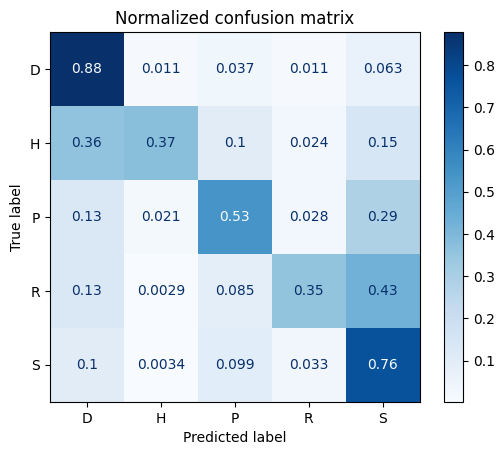

In [44]:
rfcm = [
    ("Normalized confusion matrix", "true"),
]
for title, normalize in rfcm:
    disp = ConfusionMatrixDisplay.from_estimator(
        rf,
        X_test,
        y_test,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [45]:
param_grid = {
    'n_estimators': [30,100],
    'max_depth': [2,8],
    'min_samples_split': [6,12],
    'min_samples_leaf': [10, 12],
    'max_features': ['sqrt']
}

random_search = RandomizedSearchCV(RandomForestClassifier(),
                                   param_grid, cv = 5, n_iter = 10, n_jobs = -1,  random_state=42)
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print("Best parameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

Best parameters:  {'n_estimators': 100, 'min_samples_split': 6, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'max_depth': 8}
Best score:  0.5469548047251461


Classification report on tuned model, balanced accuracy, train and test accuracies.

In [46]:
y_pred_new = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_new))
print("Confusion Matrix", confusion_matrix(y_test, y_pred_new))
print('Training Accuracy score', best_rf.score(X_train, y_train))
print('Test Accuracy score', best_rf.score(X_test, y_test))
print('Balanced Accuracy score', balanced_accuracy_score(y_test, y_pred_new))

              precision    recall  f1-score   support

           D       0.58      0.84      0.68       819
           H       0.68      0.05      0.08       287
           P       0.63      0.39      0.49       634
           R       0.60      0.17      0.26       340
           S       0.50      0.70      0.58       882

    accuracy                           0.55      2962
   macro avg       0.60      0.43      0.42      2962
weighted avg       0.58      0.55      0.50      2962

Confusion Matrix [[691   2  21   7  98]
 [184  13  20   4  66]
 [117   3 250  12 252]
 [ 53   0  14  57 216]
 [156   1  90  15 620]]
Training Accuracy score 0.6410070901461439
Test Accuracy score 0.550641458474004
Balanced Accuracy score 0.43078493642985255


Normalized confusion matrix
[[0.84371184 0.002442   0.02564103 0.00854701 0.11965812]
 [0.64111498 0.04529617 0.06968641 0.01393728 0.22996516]
 [0.18454259 0.00473186 0.39432177 0.01892744 0.39747634]
 [0.15588235 0.         0.04117647 0.16764706 0.63529412]
 [0.17687075 0.00113379 0.10204082 0.0170068  0.70294785]]


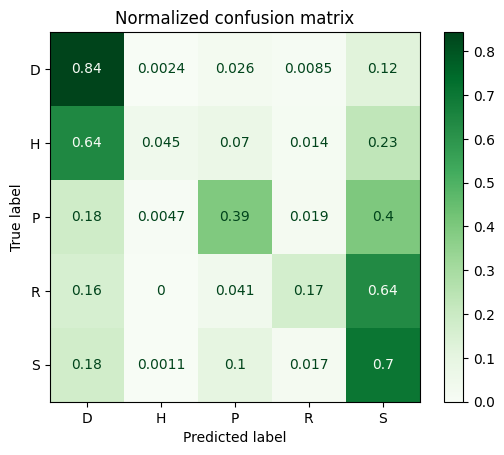

In [47]:
rfcm = [
    ("Normalized confusion matrix", "true"),
]
for title, normalize in rfcm:
    disp = ConfusionMatrixDisplay.from_estimator(
        best_rf,
        X_test,
        y_test,
        cmap=plt.cm.Greens,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

RandomSearchCV was used for versatility! With hyperparameter tuning overfitting was rectified but at the expense of the balanced accuracy score.there is a 9% gap between the train and test accuracies. It is expected because of how large the dataset is.

In [48]:
from sklearn.metrics import roc_auc_score
y_score = best_rf.fit(X_train, y_train).predict_proba(X_test)
micro_roc_auc_ovr = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average="micro",
)
macro_roc_auc_ovr = roc_auc_score(
     y_test,
     y_score,
     multi_class="ovr",
     average="macro",
 )

print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{micro_roc_auc_ovr:.2f}")
print(f"Macro-average One-vs-Rest ROC AUC score:\n{macro_roc_auc_ovr:.2f}")

Micro-averaged One-vs-Rest ROC AUC score:
0.85
Macro-average One-vs-Rest ROC AUC score:
0.84


Gaussian Naive Bayes

label encoder(eventhough not needed it was used for good practice) and train test split was implented!

In [49]:
le = LabelEncoder()
y = le.fit_transform(y)
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3,random_state=42)
gnb = GaussianNB()

gnb.fit(X_train, y_train)

GaussianNB()

Created a normalised confusion matrix (easier to read), classification report of raw data, balanced accuracy and train-test accuracy.

Normalized confusion matrix
[[0.84981685 0.05372405 0.02564103 0.01709402 0.05372405]
 [0.76655052 0.1010453  0.04878049 0.03135889 0.05226481]
 [0.38328076 0.15141956 0.22239748 0.10883281 0.1340694 ]
 [0.25882353 0.16176471 0.11764706 0.19117647 0.27058824]
 [0.32312925 0.08390023 0.15192744 0.08503401 0.35600907]]


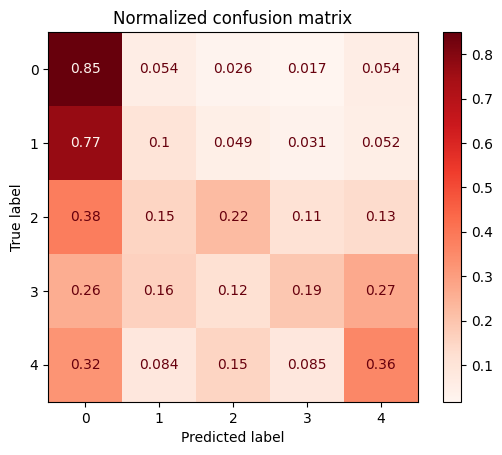

In [50]:
gnbcm = [
    ("Normalized confusion matrix", "true"),
]
for title, normalize in gnbcm:
    disp = ConfusionMatrixDisplay.from_estimator(
        gnb,
        X_test,
        y_test,
        cmap=plt.cm.Reds,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

No overfitting which is good!
However, weak raw model.


In [51]:
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print(classification_report(y_test, y_pred_gnb))
print("Confusion Matrix", confusion_matrix(y_test, y_pred_gnb))
print('Training Accuracy score', gnb.score(X_train, y_train))
print('Test Accuracy score', gnb.score(X_test, y_test))
print('Balanced Accuracy score', balanced_accuracy_score(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.45      0.85      0.59       819
           1       0.10      0.10      0.10       287
           2       0.40      0.22      0.29       634
           3       0.28      0.19      0.23       340
           4       0.57      0.36      0.44       882

    accuracy                           0.42      2962
   macro avg       0.36      0.34      0.33      2962
weighted avg       0.42      0.42      0.39      2962

Confusion Matrix [[696  44  21  14  44]
 [220  29  14   9  15]
 [243  96 141  69  85]
 [ 88  55  40  65  92]
 [285  74 134  75 314]]
Training Accuracy score 0.4200549848068297
Test Accuracy score 0.42032410533423364
Balanced Accuracy score 0.3440890326415622


Hyperparameter tuning is not required, however, GaussianNB model can be scaled. The GaussianNB is the only Naive Bayes model that can be scaled (although optional).

In [52]:
#scaling
scaler = StandardScaler().fit(X)

In [53]:
X_Scaled = scaler.transform(X)

In [54]:
X_train_scaled,X_test_scaled,y_train,y_test = train_test_split(X_Scaled, y, test_size=0.3,random_state=42)

Evaluating the data with the scaled features!

In [55]:
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_gnb))
print("Confusion Matrix", confusion_matrix(y_test, y_pred_gnb))
print('Training Accuracy score', gnb.score(X_train, y_train))
print('Test Accuracy score', gnb.score(X_test, y_test))
print('Balanced Accuracy score', balanced_accuracy_score(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.45      0.85      0.59       819
           1       0.10      0.10      0.10       287
           2       0.40      0.22      0.29       634
           3       0.28      0.19      0.23       340
           4       0.57      0.36      0.44       882

    accuracy                           0.42      2962
   macro avg       0.36      0.34      0.33      2962
weighted avg       0.42      0.42      0.39      2962

Confusion Matrix [[696  44  21  14  44]
 [220  29  14   9  15]
 [243  96 141  69  85]
 [ 88  55  40  65  92]
 [285  74 134  75 314]]
Training Accuracy score 0.27810736507017797
Test Accuracy score 0.2765023632680621
Balanced Accuracy score 0.3440890326415622


Balanced Accuracy remain almost unchanged and the classification report was exactly the same. However, the training and testing accuracies have decreased dramatically but there is no overfitting/underfitting.



**Confusion matrix heatmap** (Final (Normalised))

Normalized confusion matrix
[[0.84981685 0.05372405 0.02564103 0.01709402 0.05372405]
 [0.76655052 0.1010453  0.04878049 0.03135889 0.05226481]
 [0.38328076 0.15141956 0.22239748 0.10883281 0.1340694 ]
 [0.25882353 0.16176471 0.11764706 0.19117647 0.27058824]
 [0.32312925 0.08390023 0.15192744 0.08503401 0.35600907]]


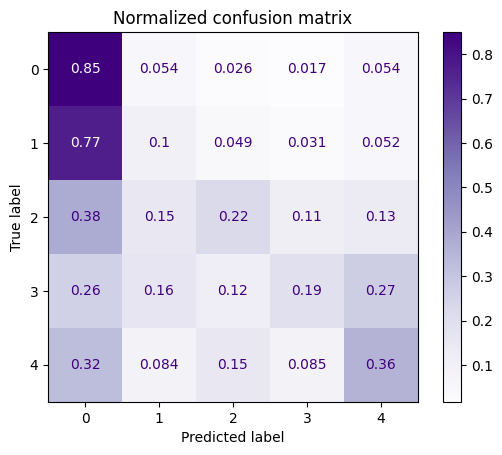

In [56]:
gnbcm = [
    ("Normalized confusion matrix", "true"),
]
for title, normalize in gnbcm:
    disp = ConfusionMatrixDisplay.from_estimator(
        gnb,
        X_test_scaled,
        y_test,
        cmap=plt.cm.Purples,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

MACRO AND MICRO AVERAGE (GaussianNB)

In [57]:
from sklearn.metrics import roc_auc_score
y_score = gnb.fit(X_train, y_train).predict_proba(X_test)
micro_roc_auc_ovr = roc_auc_score(
    y_test,
    y_score,
    multi_class="ovr",
    average="micro",
)
macro_roc_auc_ovr = roc_auc_score(
     y_test,
     y_score,
     multi_class="ovr",
     average="macro",
 )

print(f"Micro-averaged One-vs-Rest ROC AUC score:\n{micro_roc_auc_ovr:.2f}")
print(f"Macro-average One-vs-Rest ROC AUC score:\n{macro_roc_auc_ovr:.2f}")

Micro-averaged One-vs-Rest ROC AUC score:
0.72
Macro-average One-vs-Rest ROC AUC score:
0.71


References:

Data Analytics Lab (2025). How to Implement Random Forest For Multi-Class Classification | Scikit Learn Tutorial. [online] YouTube. Available at: https://www.youtube.com/watch?v=5ONlGP0Nx3Q (Accessed 9 February 2026).

Stack Overflow. (2021). How to get the training accuracy in Scikit-learn RandomForest? [online] Available at: https://stackoverflow.com/questions/69829226/how-to-get-the-training-accuracy-in-scikit-learn-randomforest (Accessed 17 February 2026)

Scikit-learn (n.d.). Receiver Operating Characteristic (ROC). [online] scikit-learn. Available at: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html. (Accessed 20 February 2026)

GeeksforGeeks (2023). Gaussian Naive Bayes. [online] GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/gaussian-naive-bayes/ (Accessed 20 February 2026)

Bhavesh Bhatt (2019). Scaling Inputs during Prediction using Sklearn’s StandardScalar. [online] YouTube. Available at: https://www.youtube.com/watch?v=4zX-iBDRn38 (Accessed 20 February 2026)

scikit-learn (2019). Confusion matrix — scikit-learn 0.22 documentation. [online] Scikit-learn.org. Available at: https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html (Accessed 23 February 2026)

Use of AI:

Generative AI (copilot) was used for advice on parameters